# De bits a qubits

- Los estados clásicos para la computación son 0 ó 1.
- En mecánica cuántica, un estado puede estar en **superposición**, es decir, puede ser 0 y 1 simultaneamente.

In [ ]:
#!pip install cudaq numpy qutip\>=5 matplotlib\>=3.5

In [23]:
import matplotlib.pyplot as plt
import numpy as np
from IPython.display import IFrame

# Números complejos

Un **número complejo** $z$ es una expresión de la forma $z=x+iy$, donde $x$ y $y$ son números reales, y donde $i^2=-1$. $i$ recibe el nombre de **unidad imaginaria**. La **parte real** de $z$, denotada como $\text{Re}(z)$, es el número $x$ y la **parte imaginaria** de $z$, denotada como $\text{Im}(z)$, es el número $y$. El conjunto $\mathbb{C}$ de todos los números complejos $x+iy$ puede identificarse con el conjunto de puntos $(x,y)$ del plano cartesiano y por esta representación es llamado el **plano complejo**. El eje $X$ es llamado el **eje real** y el eje $Y$ es llamado el **eje imaginario**.

Algunas operaciones importantes con números complejos son:

- **Conjugado complejo**: $\overline{(x+iy)}=(x+iy)^*=(x-iy)$
- **Módulo o norma**: $r=|x+iy|=\sqrt{x^2 + y^2}$, mide la distancia del origen al punto $(x,y)$
- **Argumento o fase**: $\varphi=\text{arg}(x+iy)=\arctan(\frac{y}{x})$, mide el ángulo formado entre el eje real positivo y la recta que une el origen con el punto $(x,y)$
- **Suma compleja**: $(x+iy)+(u+iv)=(x+u)+i(y+v)$
- **Producto complejo**: $(x+iy)(u+iv)=(xu-yv)+i(xv+yu)$

<img src="imagenes/Plano_complejo.png" alt="planocomplejo" width="500" height="300">

In [5]:
import cmath

In [20]:
# En python la unidad imaginaria se denota por j en lugar de i
z = 3 + 2j
print(z)
type(z)

(3+2j)


complex

In [8]:
z2 = complex(3, 2)
print(z2)

(3+2j)


In [9]:
print(z==z2)

True


In [10]:
z.conjugate()

(3-2j)

In [16]:
# Operaciones básicas
z1 = 1 + 2j
z2 = 3 - 5j

print(z1+z2)
print(z1*z2)

(4-3j)
(13+1j)


In [19]:
# Módulo y fase
z3 = 3 + 4j
print(abs(z3))
print(cmath.phase(z3)) # fase en radianes

5.0
0.9272952180016122


# Exponenciales complejas

Existe otra manera de escribir un número complejo $z$, la cual se conoce como la **forma polar** del complejo $z$. Para escribir la forma polar vamos a utilizar la **identidad de Euler**. Dado un ángulo $\theta$ tenemos que $e^{i\theta}=\cos(\theta)+i\sin(\theta)$. La representación polar de un numero complejo esta dada por $z=x+iy=r(\cos(\varphi)+i\sin(\varphi))=re^{i\varphi}$, donde $r=|z|$ y $\varphi=\text{arg}(z)$.

Podemos reescribir las operaciones básicas en la forma polar.

- Conjugado complejo: $\overline{e^{i\varphi}}=e^{-i\varphi}$
- Módulo o norma: $|re^{i\varphi}|=r$
- Producto complejo: $e^{i\varphi}e^{i\theta}=e^{i(\varphi+\theta)}$

La exponencial compleja se puede relacionar con las funciones trigonometricas seno y coseno.

- $\cos(\varphi)=\frac{e^{i\varphi}+e^{-i\varphi}}{2}$
- $\sin(\varphi)=\frac{e^{i\varphi}-e^{-i\varphi}}{2i}$

<img src="imagenes//exponencial_compleja.svg" alt="planocomplejo" width="500" height="300">

In [24]:
# Conversión a forma polar
z = 3 + 4j
r = abs(z)
phi = cmath.phase(z)
print(r, phi)
zp = cmath.polar(z)
print(zp)
type(zp)

5.0 0.9272952180016122
(5.0, 0.9272952180016122)


tuple

In [25]:
# Conversión a forma rectangular
zr = cmath.rect(zp[0], zp[1])
print(zr)
type(zr)

(3.0000000000000004+3.9999999999999996j)


complex

# Vectores

Por lo general, un **vector es una lista de cosas**. Los usamos cuando queremos representar una coordenada en un espacio de dimensión mayor a 1.

Cuando un vector es solo una lista de números, lo podemos visualizar como una flecha en el espacio. Por ejemplo, visualizamos el vector $(4,2)$ como una flecha:

<img src="imagenes/mi_vector.png" alt="vector" width="500" height="300">

## Notación vectorial

Hay muchas maneras de escribir vectores. En general, las más conocidas son los vectores columna y renglon.

$$\mathbf{v} = \hat{v} = \begin{bmatrix}
v_x & v_y & v_z
\end{bmatrix} = \begin{bmatrix}
v_x \\ v_y \\ v_z
\end{bmatrix}$$

In [7]:
# Vectores utilzando numpy
v_x = 5
v_y = 6
v_z = 8

v = np.array([v_x, v_y, v_z])
print(v)

[5 6 8]


**Operaciones entre vectores**

$$
\mathbf{u} \pm \mathbf{v} = 
\begin{bmatrix} u_x \\ u_y \\ u_z \end{bmatrix} \pm 
\begin{bmatrix} v_x \\ v_y \\ v_z \end{bmatrix} = 
\begin{bmatrix} u_x \pm v_x \\ u_y \pm v_y \\ u_z \pm v_z \end{bmatrix}
$$

$$k \mathbf{u} = k \begin{bmatrix} u_x \\ u_y \\ u_z \end{bmatrix} = 
\begin{bmatrix} k u_x \\ k u_y \\ k u_z \end{bmatrix}$$

$$\|\mathbf{v}\| = \sqrt{v_x^2 + v_y^2 + v_z^2}$$

**Vectores unitarios**

Utilizando las operaciones de suma y multiplicación por escalar, podemos definir una tercera notación para vectores, se le conoce como la notación de vectores unitarios:

$$\mathbf{i} = \begin{bmatrix} 1 \\ 0 \\ 0 \end{bmatrix}, \quad 
\mathbf{j} = \begin{bmatrix} 0 \\ 1 \\ 0 \end{bmatrix}, \quad 
\mathbf{k} = \begin{bmatrix} 0 \\ 0 \\ 1 \end{bmatrix}$$

Podemos escribir cualquier vector como una suma de estos tres vectores unitarios.

$$\mathbf{v} = v_x \mathbf{i} + v_y \mathbf{j} + v_z \mathbf{k} = 
v_x \begin{bmatrix} 1 \\ 0 \\ 0 \end{bmatrix} +
v_y \begin{bmatrix} 0 \\ 1 \\ 0 \end{bmatrix} +
v_z \begin{bmatrix} 0 \\ 0 \\ 1 \end{bmatrix} =
\begin{bmatrix} v_x \\ v_y \\ v_z \end{bmatrix}$$

A esto se le conoce como una combinación lineal.

# Qubits

Un qubit es un sistema cuántico que puede tomar valores $\ket{0}$ ó $\ket{1}$. Adicionalmente puede tomar cualquier valor de la forma $\alpha \ket{0} + \beta \ket{1}$, tal que $\alpha, \beta \in \mathbb{C}$ y $|\alpha|^2+|\beta|^2=1$.

Mientras que un bit sólo puede encontrarse en uno de dos estados en un momento dado, un qubit puede encontrarse en dos estados simultáneamente. Esto sugiere que podríamos manejar la información de manera más eficiente con qubits que con bits. Pero hay un inconveniente, no necesariamente podemos acceder a toda la información almacenada en un qubit.

Vamos a establecer una notación que nos permita describir estados y realizar operaciones cuánticas sobre ellos. Ya hemos introducido los estados $\ket{0}$ y $\ket{1}$. Podemos identificar $\ket{0}$ con el vector $\begin{bmatrix} 1 \\ 0 \end{bmatrix}$ y $\ket{1}$ con el vector $\begin{bmatrix} 0\\ 1\end{bmatrix}$. Entonces, cualquier otro estado cuántico $\ket{\psi}$ puede escribirse como una combinación lineal de $\ket{0}$ y $\ket{1}$. En otras palabras, los estados cuánticos toman la forma

$$
\ket{\psi} = \alpha\ket{0}+\beta\ket{1},
$$

donde $\alpha$ y $\beta$ son números complejos que satisfacen la ecuación $|\alpha|^2+|\beta|^2 = 1$. A los coeficientes $\alpha$ y $\beta$ se les denomina **amplitudes de probabilidad** o, simplemente, **amplitudes**.

Un qubit puede visualizarse como un vector unitario que apunta en cualquier dirección en un espacio tridimensional. En otras palabras, podemos visualizar un qubit como un vector sobre una esfera. En la literatura convencional, esta esfera se conoce como la esfera de Bloch. Vamos a identificar el vector que apunta hacia arriba (es decir, en la dirección del eje $z$ positivo) con el estado cero.

<img src="https://raw.githubusercontent.com/NVIDIA/cuda-q-academic/main/images/Blochsphere0.png" alt="Bloch sphere representation of \ket{0}" width="300"/>

El vector que apunta hacia abajo representará el estado uno, que se abrevia como $\ket{1}$. Además de los estados $\ket{0}$ y $\ket{1}$, existen infinitos estados cuánticos. Cada uno de los infinitos vectores de la esfera de Bloch representa un estado diferente.

<img src="https://raw.githubusercontent.com/NVIDIA/cuda-q-academic/main/images/BlochsphereManyStates.png" alt="Several states represented on the Bloch Sphere" width="300"/>

Veamos cómo se representa la expresión $\ket{\psi} = \alpha\ket{0}+\beta\ket{1}$ en la esfera de Bloch. En primer lugar, reescribimos los coeficientes $\alpha$ y $\beta$ de la siguiente manera:

$$
\alpha = \cos(\frac{\theta}{2})\text{ y }\beta = \sin(\frac{\theta}{2})e^{i\varphi},
$$

donde $\theta$ es un valor en el intervalo $[0,\pi]$ y $\varphi$ es un valor en el intervalo $[0,2\pi)$. Utilizando coordenadas esféricas, podemos representar el estado en la esfera de Bloch siguiendo la convención que se muestra en la imagen siguiente:

<img src="https://raw.githubusercontent.com/NVIDIA/cuda-q-academic/main/images/BlochsphereAngles.png" alt="Image of a State on the Bloch Sphere with spherical coordinates indicated" width="300"/>

Por ejemplo, el estado $$\ket{-} = \frac{1}{\sqrt{2}}\ket{0}-\frac{1}{\sqrt{2}}\ket{1}$$ puede escribirse como

$$
\ket{-} = \cos(\frac{\pi}{4})\ket{0}+\sin(\frac{\pi}{4})e^{i\pi}\ket{1},
$$

donde $\theta = \frac{\pi}{2}$ y $\varphi = \pi$.

Una vez que hayamos hallado $\theta$ y $\varphi$, podemos representar el estado en la esfera de Bloch. En concreto, el estado $\ket{-}$ es un vector que apunta en la dirección del eje $x$ negativo, lo que explica en parte el nombre “estado menos”.

<img src="https://raw.githubusercontent.com/NVIDIA/cuda-q-academic/main/images/BlochsphereMinus.png" alt="Minus state represented on the Bloch Sphere" width="300"/>

Podemos interactuar libremente con la esfera de Bloch en el siguiente [link](https://nvidia.github.io/cuda-q-academic/quantum-applications-to-finance/images/quantum_coin_widget.html).

> **Nota:** Para realizar cualquier cálculo, necesitaremos un mecanismo que permita cambiar el estado de un qubit. La computación cuántica nos permite cambiar el estado de un solo qubit mediante operaciones cuánticas que pueden visualizarse como rotaciones de la esfera.

# Uso de CUDA-Q para definir y visualizar un estado cuántico

**¿Qué es CUDA-Q?**

[CUDA-Q](https://developer.nvidia.com/cuda-q) es una plataforma diseñada para el desarrollo de aplicaciones híbridas. Es decir, CUDA-Q permite programar en un entorno heterogéneo que aprovecha no solo los procesadores cuánticos y los simuladores cuánticos, sino también las CPUs y las GPUs. CUDA-Q es compatible con CUDA y con el ecosistema de software de CUDA para aplicaciones aceleradas por GPU. CUDA-Q incluye bibliotecas tanto para C++ como para Python.

Vamos a utilizar CUDA-Q para crear los estados cuánticos de qubits individuales y visualizarlos en la esfera de Bloch. CUDA-Q utiliza el decorador `cudaq.kernel` en las funciones para definir estados cuánticos.

[ 0.70710678+0.j -0.70710678+0.j]


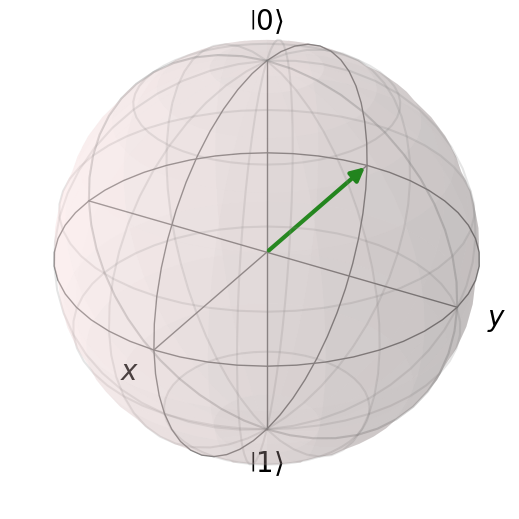

In [11]:
import cudaq
import qutip

c = np.array([complex(np.sqrt(2)/2, 0), complex(-np.sqrt(2)/2,0)])

print(c)

@cudaq.kernel
def minus_state():
    q = cudaq.qvector(c)

sphere = cudaq.add_to_bloch_sphere(cudaq.get_state(minus_state))
cudaq.show(sphere)

Una vez que hayamos definido un kernel, podemos utilizar el comando `get_state` para leer el estado del mismo. A continuación, podemos añadir este estado a una esfera de Bloch mediante `add_to_bloch_sphere`, y mostrarla con el comando `show`.

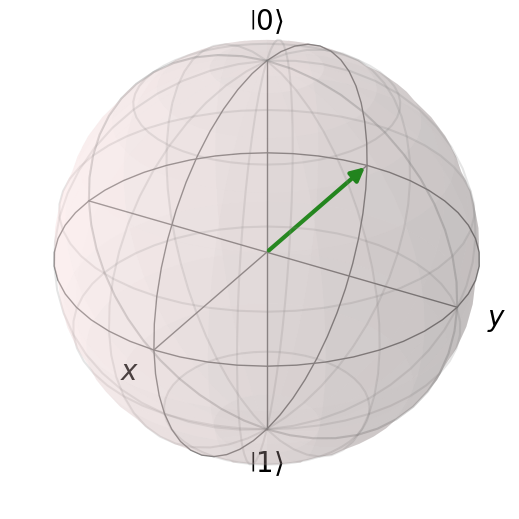

In [12]:
sphere = cudaq.add_to_bloch_sphere(cudaq.get_state(minus_state))
cudaq.show(sphere)

<div style="background-color: #f9fff0; border-left: 6px solid #76b900; padding: 15px; border-radius: 4px;">
    <h3 style="color: #76b900; margin-top: 0;"> Ejercicio 1:</h3>
    <p style="font-size: 16px; color: #333;">
      Cree una esfera de Bloch que muestre los siguientes estados: $\ket{0}, \ket{1}, \ket{+}$, y $\ket{i} = \frac{1}{\sqrt{2}}\ket{0}+\frac{i}{\sqrt{2}}\ket{1}$.
    </p>
</div>

>**CUDA-Q Tip:** El comando `add_to_bloch_sphere` puede aceptar un solo estado, como hemos mostrado anteriormente, o una lista de estados que se pueden representar gráficamente en una cuadricula de esferas de Bloch independientes.

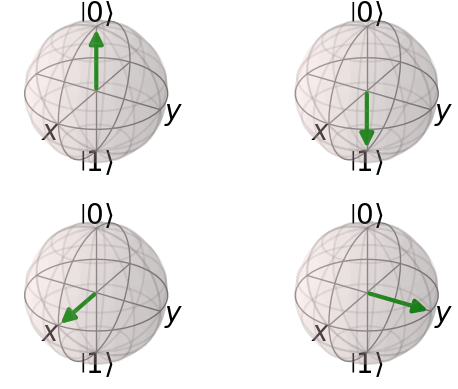

In [13]:
c0 = [complex(1, 0), complex(0, 0)]
c1 = [complex(0, 0), complex(1, 0)] # |1>
cMas = [complex(np.sqrt(2)/2, 0), complex(np.sqrt(2)/2,0)] # |+>
ci = [complex(np.sqrt(2)/2, 0), complex(0,np.sqrt(2)/2)] # |i>

list_of_states = [c0,c1,cMas,ci]

# Define a cudaq.kernel to represent the state with given coefficients
@cudaq.kernel
def kernel_for_state(c:list[complex]):
    q = cudaq.qvector(c)

# Define a list of Bloch spheres, one sphere for each of the 4 states
blochSphereList = []
# Generate the 4 states by calling the kernel_for_state kernel for each list of coefficients
for c in list_of_states:
    sphere = cudaq.add_to_bloch_sphere(cudaq.get_state(kernel_for_state, c))
    blochSphereList.append(sphere)

# Display the Bloch spheres side by side in 2 rows and 2 columns
cudaq.show(blochSphereList, nrows=2, ncols=2)

# Nuestro primer programa cuántico

Ahora que entendemos los qubits y hemos creado representaciones de estados cuánticos en CUDA-Q, pasemos al cómputo cuántico propiamente dicho. Estamos listos para escribir nuestro primer programa cuántico.

La estructura general de un programa cuántico es:

* Codificar la información en el estado cuántico inicializando uno o varios qubits
* Manipular el estado cuántico de los qubits con **compuertas cuánticas**
* Extraer información del estado cuántico **midiendo** el estado de los qubits

Estos tres pasos se describen en el siguiente diagrama:

<img src="https://raw.githubusercontent.com/NVIDIA/cuda-q-academic/main/images/circuit.png" alt="image of a quantum circuit with the three partsL encode information, manipulate quantum states, extract information" width="300"/>

Veremos algunos ejemplos sencillos de programas cuánticos para ilustrar estos pasos. Comencemos con dos programas cuánticos muy sencillos: un programa para invertir bits y un programa “Hello World”. A través de estos ejemplos, aprenderemos dos conceptos importantes: la **medición** y las **compuertas cuánticas**.

# Bit Flip

Repasemos los tres pasos para escribir el programa "Bit Flip" en CUDA-Q. Este programa es una versión cuántica de la operación clásica "NOT", que invierte un bit de $0$ a $1$ y viceversa.

Esquema del programa Bit Flip: Pasar de $\ket{0}$ a $\ket{1}$.

* Inicializar el estado cero
* Manipular el estado cuántico aplicando la compuerta de inversión de bits
* Medir el qubit

Comencemos por definir un kernel y especificar que este kernel solo contiene un qubit.

> **CUDA-Q Tip:** El comando `cudaq.qvector` tiene dos funciones. Cuando `cudaq.qvector` recibe una lista, tal como vimos en el ejemplo `minus_state`, el kernel se inicializa en el estado correspondiente a los coeficientes de la lista. En el ejemplo siguiente, `cudaq.qvector` aceptará un valor `int` y asignará ese número de qubits al núcleo. Estos qubits, por defecto, se inicializan en el estado cero.

In [14]:
# Writing a bit flip program one step at a time
# Step 1: Create a kernel with one qubit initialized in the zero state

@cudaq.kernel
def bitflip():
    # Allocate one qubit to the kernel. It is by default initialized in the zero state
    qubit = cudaq.qvector(1)

    # Manipulate the quantum state by applying the bit flip gate (the `x` gate)
    # To be completed later in this section

Comprobemos que el código anterior ha inicializado un qubit en el estado cero obteniendo su estado y representándolo en la esfera de Bloch.

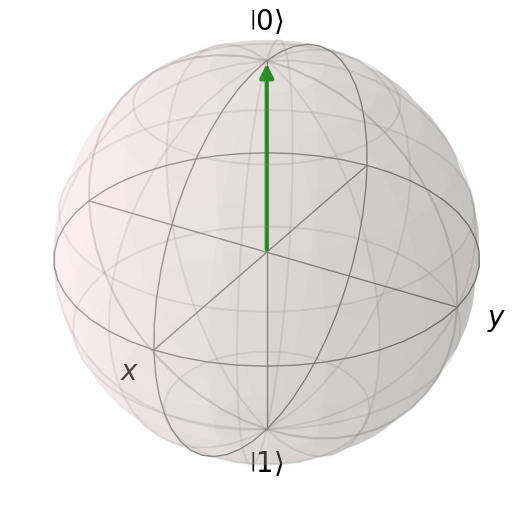

In [15]:
# Visualizing a state of the bitflip kernel before the x gate is applied

# Define a sphere object representing the state of the single qubit
sphere = cudaq.add_to_bloch_sphere(cudaq.get_state(bitflip))

# Display the Bloch sphere
cudaq.show(sphere)

A continuación, queremos manipular el estado cero, $\ket{0}$, y cambiarlo al estado uno, $\ket{1}$. Una forma de hacerlo es rotando la esfera de Bloch 180 grados alrededor del eje x. Matemáticamente, esto se puede llevar a cabo mediante una multiplicación de matrices. Recordemos que $\ket{0}=\begin{bmatrix}1\\0\end{bmatrix}$ y $\ket{1}=\begin{bmatrix}0\\1\end{bmatrix}$. Observa que la matriz $X=\begin{bmatrix}0 & 1 \\ 1 & 0 \end{bmatrix}$ tiene la propiedad que estamos buscando. Es decir, multiplicar el estado cero por $X$ devuelve el estado uno: $$X\ket{0} = \ket{1}.$$

En general, podemos cambiar un estado cuántico multiplicando por una **matriz unitaria**, denotada como $U$. La propiedad que nos interesa de la matriz $U$ es: $$|U\ket{\psi}|=|\ket{\psi}|$$, es decir, convierte un estado cuántico en otro.

En el contexto de un programa cuántico, nos referimos a la multiplicación de una matriz unitaria $U$ por un estado cuántico, como la aplicación de la compuerta $U$. En CUDA-Q, la puerta $X$ se implementa con la sintaxis `x()`.

> **CUDA-Q Tip:** Puedes ver todas las operaciones de puertas cuánticas integradas en CUDA-Q [aquí](https://nvidia.github.io/cuda-quantum/latest/api/default_ops.html#unitary-operations-on-qubits).

Vamos a aplicar la puerta `x` al qubit de nuestro kernel.

In [16]:
# Writing a bit flip program one step at a time
# Step 2: Apply the X-gate

@cudaq.kernel
def bitflip():
    # Allocate 1 qubit initialized in the zero state
    qubit = cudaq.qvector(1)

    # Manipulate the quantum state by applying the bit flip gate (the `x` gate)
    x(qubit[0]) # Apply the x-gate to the first qubit, which is indexed with 0

Usemos de nuevo el comando `get_state` para comprobar que el kernel `bitflip` hace lo que esperamos, es decir, cambiar el estado de $\ket{0}$ a $\ket{1}$.

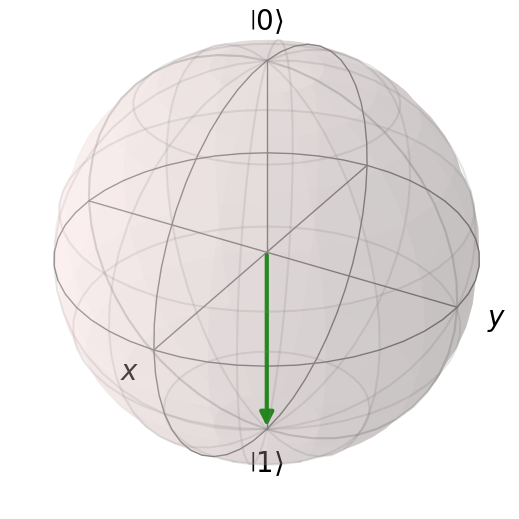

In [17]:
# Visualizing the action of the bitflip kernel

sphere = cudaq.add_to_bloch_sphere(cudaq.get_state(bitflip))
cudaq.show(sphere)

El proceso de visualizar el estado de un kernel en una esfera de Bloch mediante `get_state` no es muy eficiente y no resultará útil cuando tengamos muchos qubits. En primer lugar, las esferas de Bloch solo pueden representar el estado de un único qubit. Además, el comando `get_state` puede resultar excesivo para la cantidad de información que podemos o necesitamos recuperar de varios qubits.

Afortunadamente, existen otras herramientas de visualización que podemos utilizar para verificar los kernels que creamos. Algunos kernels pueden representarse como diagramas de circuitos cuánticos. CUDA-Q incluye el comando `cudaq.draw` para generar una imagen ASCII del diagrama de circuitos de un kernel. Básicamente, cada fila del diagrama de circuitos representa un qubit. En este caso, solo tenemos un qubit, que por defecto se denomina `q0` en el diagrama. Las operaciones aplicadas al qubit se muestran como cuadros y se leen de izquierda a derecha. Nuestro kernel tiene solo una puerta, la puerta `x`. Analizaremos estos diagramas con más detalle más adelante, después de haber visto algunos otros ejemplos.

In [18]:
print(cudaq.draw(bitflip))

     ╭───╮
q0 : ┤ x ├
     ╰───╯



El paso final de nuestro primer programa cuántico consiste en **extraer información** del estado cuántico del qubit. Esto se hace con el comando `sample`. El comando `sample` ejecuta el kernel y realiza las mediciones que le indiquemos (`shots_count`).

En nuestro ejemplo, aplicar la puerta `x` al estado cero siempre dará como resultado el estado uno, a menos, claro está, que haya errores en la ejecución del circuito. Ese es un tema para otro día. Ahora, supondremos que todas nuestras ejecuciones del kernel están libres de errores. En este caso, esperaríamos ver que se devuelve el estado uno para cada ejecución del kernel.

In [19]:
# Sampling the bit flip kernel
shots = 123
results = cudaq.sample(bitflip, shots_count=shots)

# The output of the sample command looks like a dictionary, but is of a different type
print("Results from sampling {} times: {}\n".format(shots, results))
print("Although the results appear to be of type dict,\nthe type of the results from the sample\ncommand is {}.\n".format(type(results)))

# Often it will be useful to identify the most probable outcome
# and the probability of this outcome
most_probable_result = results.most_probable()
probability = results.probability(most_probable_result)
print("Most probable result: " + most_probable_result)
print("Measured with probability " + str(probability), end='\n\n')

Results from sampling 123 times: { 1:123 }


Although the results appear to be of type dict,
the type of the results from the sample
command is <class 'cudaq.mlir._mlir_libs._quakeDialects.cudaq_runtime.SampleResult'>.

Most probable result: 1
Measured with probability 1.0



# Hello World

Para comprender mejor en qué se diferencian los programas cuánticos de los clásicos, veamos un programa “Hello World”, que retoma el kernel del estado "menos" y nos dará la oportunidad de analizar dos conceptos importantes: la **superposición** y la **medición**.

Hello World: Generar y medir el estado menos $\ket{-}$

* Inicializar un qubit en el estado uno
* Manipular el estado cuántico transformándolo en el estado menos
* Extraer información del estado cuántico realizando mediciones

Ya hemos creado un kernel (`minus_state`) para inicializar el estado negativo pasando una lista de coeficientes al comando `cudaq.qvector`. Existen otras formas de inicializar un estado si conocemos las operaciones de compuerta que lo generan. La compuerta Hadamard aplicada al $\ket{1}$ genera el estado $\ket{-}$.

La compuerta Hadamard es la matriz $$H = \frac{1}{\sqrt{2}}\begin{bmatrix} 1& 1 \\ 1 & -1\end{bmatrix}.$$
Observen que si multiplicamos $H$ y $\ket{1}$ obtenemos $\ket{-}$:
$$ H\ket{1} = \frac{1}{\sqrt{2}}\begin{bmatrix} 1& 1 \\ 1 & -1\end{bmatrix}\begin{bmatrix} 0 \\ 1 \end{bmatrix} = \frac{1}{\sqrt{2}}\begin{bmatrix} 1 \\ -1\end{bmatrix} = \ket{-}.$$
Este cálculo sugiere una forma de generar el estado menos:
* Primero inicializamos el estado uno y luego aplicamos la puerta de Hadamard utilizando el comando CUDA-Q `h()`.
* Esto nos deja con la pregunta: ¿cómo inicializamos el estado uno? La respuesta está implícita en el ejemplo anterior: aplicamos la puerta `x` al estado cero.

Ahora tenemos un plan, así que vamos a programarlo.

In [20]:
# Kernel for the minus state

@cudaq.kernel
def minus_kernel():
    # Allocate a qubit
    qvector = cudaq.qvector(1)

    # Initialize the state |1>
    x(qvector)

    # Apply the Hadamard gate
    h(qvector)

# Draw the circuit to check our work
print(cudaq.draw(minus_kernel))

     ╭───╮╭───╮
q0 : ┤ x ├┤ h ├
     ╰───╯╰───╯



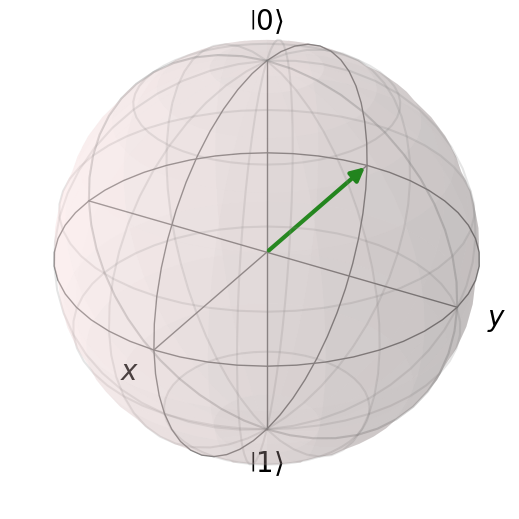

In [21]:
# Visualizing the action of the minus_kernel

sphere = cudaq.add_to_bloch_sphere(cudaq.get_state(minus_kernel))
cudaq.show(sphere)

Midamos el `minus_kernel` y analicemos los resultados.

In [22]:
# Sampling the minus kernel
shots = 100
results = cudaq.sample(minus_kernel, shots_count=shots)
print("Results from sampling {} times: {}".format(shots, results))

# Often it will be useful to identify the most probable outcome
# and the probability of this outcome
most_probable_result = results.most_probable()
probability = results.probability(most_probable_result)
print("Most probable result: " + most_probable_result)
print("Measured with probability " + str(probability), end='\n\n')

Results from sampling 100 times: { 0:44 1:56 }

Most probable result: 1
Measured with probability 0.56



Utiliza la herramienta de [visualización](https://nvidia.github.io/cuda-q-academic/quick-start-to-quantum/interactive_widget/borns-rule-widget-sampling.html). que aparece a continuación para explorar la relación entre la representación en la esfera de Bloch del estado $\ket{\psi}$ y las probabilidades de obtener un 0 o un 1 en la medición.

 <iframe src="https://nvidia.github.io/cuda-q-academic/quick-start-to-quantum/interactive_widget/borns-rule-widget-sampling.html" width="800" height="600"></iframe>